In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of trading days
n = 300

# Simulated daily returns
daily_returns = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=n
)

# Generate prices
prices = 100 * np.cumprod(
    1 + daily_returns
)

df = pd.DataFrame()

df["Close"] = prices

df.head()

,Close
0,101.093428
1,100.914969
2,102.323114
3,105.542260
4,105.153541


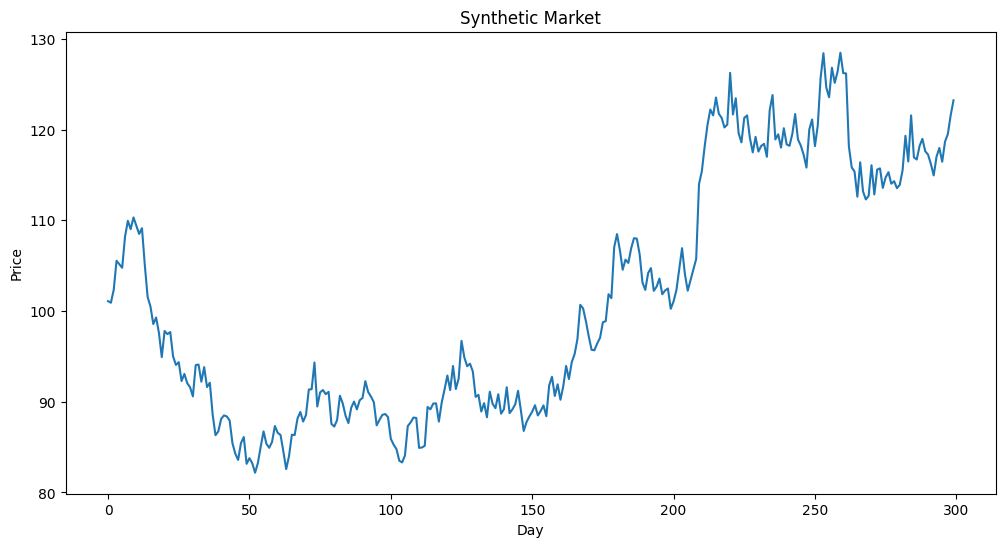

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Synthetic Market")

plt.xlabel("Day")

plt.ylabel("Price")

plt.show()

In [ ]:
df["Return"] = (
    df["Close"]
    .pct_change()
)

df.head()

,Close,Return
0,101.093428,NaN
1,100.914969,-0.001765
2,102.323114,0.013954
3,105.542260,0.031461
4,105.153541,-0.003683


In [ ]:
df["MA10"] = (
    df["Close"]
    .rolling(10)
    .mean()
)

df["Signal"] = np.where(
    df["Close"] > df["MA10"],
    1,
    0
)

df.head(15)

,Close,Return,MA10,Signal
0,101.093428,NaN,NaN,0
1,100.914969,-0.001765,NaN,0
2,102.323114,0.013954,NaN,0
3,105.542260,0.031461,NaN,0
4,105.153541,-0.003683,NaN,0
5,104.766288,-0.003683,NaN,0
6,108.180019,0.032584,NaN,0
7,109.948621,0.016349,NaN,0
8,109.026209,-0.008389,NaN,0
9,110.318300,0.011851,105.726675,1


In [ ]:
df["Cheating_Return"] = (
    df["Signal"]
    *
    df["Return"]
)

In [ ]:
df["Cheating_Equity"] = (
    1 +
    df["Cheating_Return"]
).cumprod()

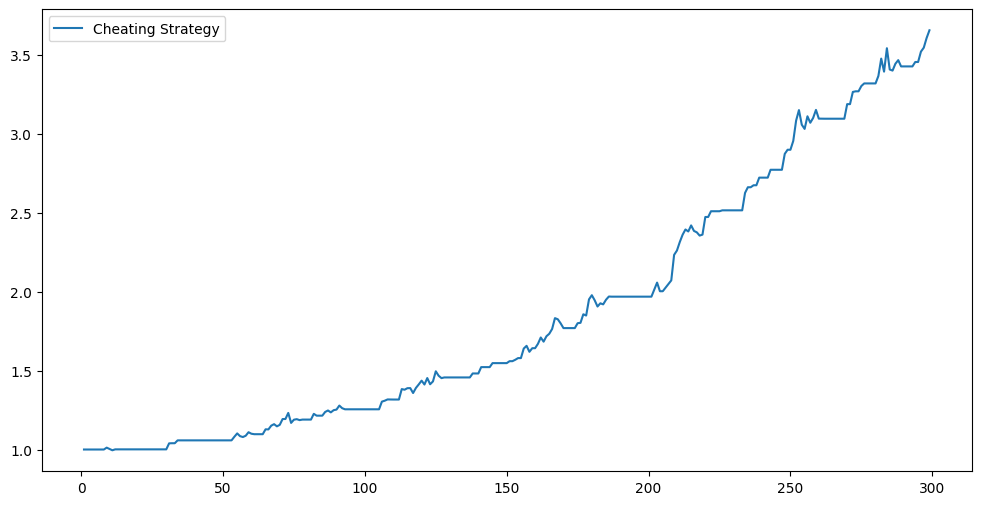

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Cheating_Equity"],
    label="Cheating Strategy"
)

plt.legend()

plt.show()

In [ ]:
df["Real_Return"] = (
    df["Signal"]
    .shift(1)
    *
    df["Return"]
)

In [ ]:
df["Real_Equity"] = (
    1 +
    df["Real_Return"]
).cumprod()

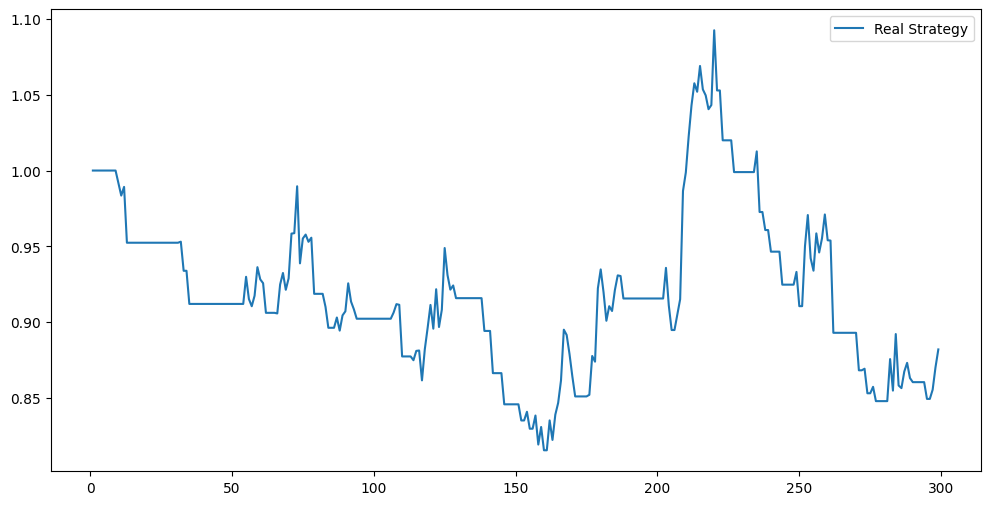

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Real_Equity"],
    label="Real Strategy"
)

plt.legend()

plt.show()

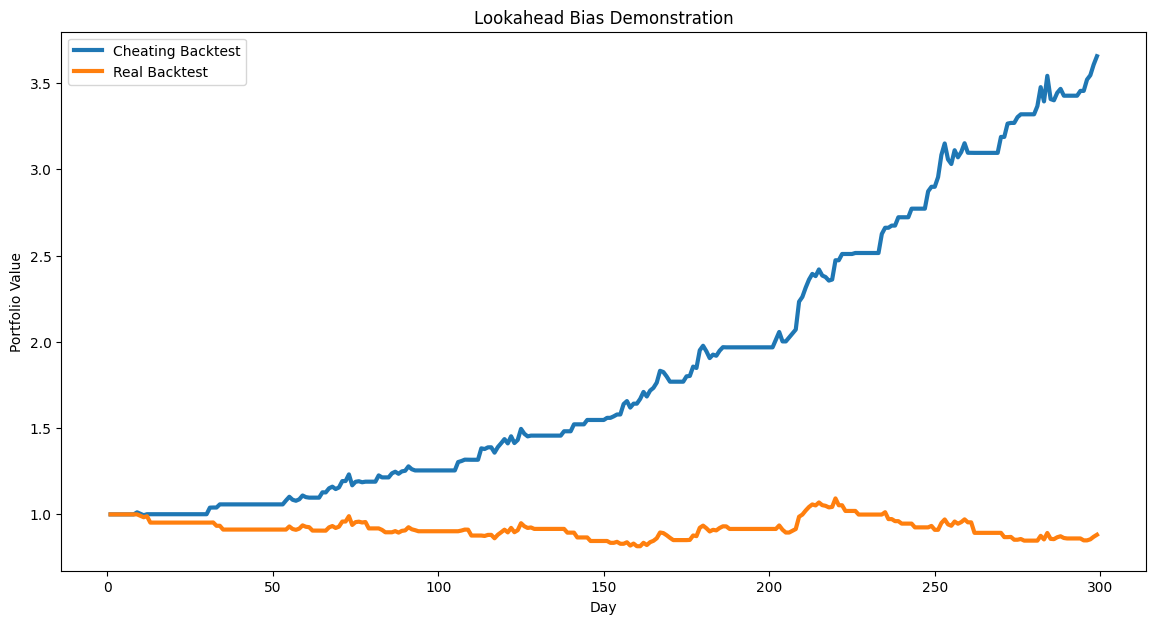

In [ ]:
plt.figure(figsize=(14,7))

plt.plot(
    df["Cheating_Equity"],
    label="Cheating Backtest",
    linewidth=3
)

plt.plot(
    df["Real_Equity"],
    label="Real Backtest",
    linewidth=3
)

plt.title(
    "Lookahead Bias Demonstration"
)

plt.xlabel("Day")

plt.ylabel("Portfolio Value")

plt.legend()

plt.show()

In [ ]:
cheating_return = (
    df["Cheating_Equity"]
    .iloc[-1]
    - 1
)

real_return = (
    df["Real_Equity"]
    .iloc[-1]
    - 1
)

print(
    "Cheating Return:",
    round(
        cheating_return * 100,
        2
    ),
    "%"
)

print(
    "Real Return:",
    round(
        real_return * 100,
        2
    ),
    "%"
)

Cheating Return: 265.59 %
Real Return: -11.8 %


In [ ]:
cheating_hit = (
    (
        df["Cheating_Return"]
        > 0
    ).sum()
    /
    df["Cheating_Return"]
    .count()
)

real_hit = (
    (
        df["Real_Return"]
        > 0
    ).sum()
    /
    df["Real_Return"]
    .count()
)

print(
    "Cheating Hit Rate:",
    round(
        cheating_hit * 100,
        2
    ),
    "%"
)

print(
    "Real Hit Rate:",
    round(
        real_hit * 100,
        2
    ),
    "%"
)

Cheating Hit Rate: 34.78 %
Real Hit Rate: 23.75 %
